# V56: Trailing Stop Loss Strategy (LQ45)

Notebook ini mengeksplorasi strategi **Reactive** menggunakan **Trailing Stop Loss**, alih-alih mengandalkan prediksi AI (Bear Signal) yang mungkin sering salah (False Alarm) di pasar Bullish.

### Konsep V56:
1.  **AI sebagai Entry**: Sinyal AI hanya digunakan untuk **BELI** (Risk ON). Jika AI > Threshold, kita masuk.
2.  **Trailing Stop sebagai Exit**: Kita **mengabaikan sinyal Bear AI**. Satu-satunya alasan untuk menjual (Risk OFF) ke Cash adalah jika nilai portofolio turun **X% dari titik tertingginya (High Watermark)**.
    *   Ini memastikan kita tidak keluar terlalu dini saat pasar hanya koreksi wajar.
    *   Ini juga memastikan kita tetap keluar (Cut Loss) jika pasar benar-benar Crash dalam (Bear Market dimulai).

### Parameter yang Diuji:
Kita akan menguji level Trailing Stop: **5%**, **10%**, dan **15%**.
Tujuannya adalah menemukan "Sweet Spot" di mana kita bisa menunggangi Bull Run (tidak kena shakeout) tetapi selamat dari Crash besar.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- LOCK RANDOMNESS ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")

Data Loaded: 712 rows


In [2]:
# --- 2. AI Training (Standard V47) ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [3]:
# --- 3. Core Logic: Trailing Stop Simulation ---

def get_mis_assets_stable(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = sorted(returns_window.columns)
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation_trailing_stop(test_dates, returns, ai_probs, threshold, 
                                 stop_loss_pct=0.10, # e.g., 10%
                                 use_ai_exit=False, # If True, exit on AI Bear signal too. If False, ONLY Trail Stop.
                                 fee=0.0025, 
                                 g_lookback=60, 
                                 rebal_period=20, 
                                 turnover_buffer=0.05):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    
    # Trailing Stop State
    high_watermark = 100.0 # Track highest Portfolio Value
    
    days_since_rebal = 999
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # --- 1. Determine Signal ---
        # Start with current state
        new_status = risk_status
        
        # AI Bull Signal (Entry Condition)
        # If we are OUT (False), check if we should Enter (True)
        if not risk_status:
            if prob > (threshold + 0.05): # Hysteresis Buffer Entry
                new_status = True
                # Reset High Watermark when entering? No, track absolute wealth.
                # But trailing stop should be relative to recent peak since entry? 
                # Standard Trailing Stop tracks peak of equity curve.
                # If we re-enter, our current val is the new base, but HWM might be higher from history.
                # Let's say Trailing Stop is active ONLY when invested.
                # So if we enter, we set HWM = current val.
                high_watermark = val
        
        # Exit Conditions (While Invested)
        elif risk_status:
            # Logic A: AI Exit (Optional)
            if use_ai_exit:
                if prob < (threshold - 0.05):
                    new_status = False
            
            # Logic B: Trailing Stop (Always Active if invested)
            # Update High Watermark
            if val > high_watermark:
                high_watermark = val
            
            # Check Drawdown from HWM
            drawdown = (high_watermark - val) / high_watermark
            if drawdown > stop_loss_pct:
                new_status = False # FORCE EXIT (STOP LOSS HIT)
                # Note: Once stopped out, we need AI Bull signal to re-enter.
        
        risk_status = new_status
        regime_changed = (risk_status != prev_risk_status)
        
        # --- 2. Portfolio Management ---
        target_weights = current_weights.copy()
        
        if not risk_status:
            # Risk OFF
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            # Risk ON
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                selected = get_mis_assets_stable(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # --- 3. Execution ---
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

Running Static (No Stop Loss)...
Running Trail Stop 5% (Ignore AI Bear)...
Running Trail Stop 10% (Ignore AI Bear)...
Running Trail Stop 15% (Ignore AI Bear)...
Running Standard AI (No Stop Loss)...


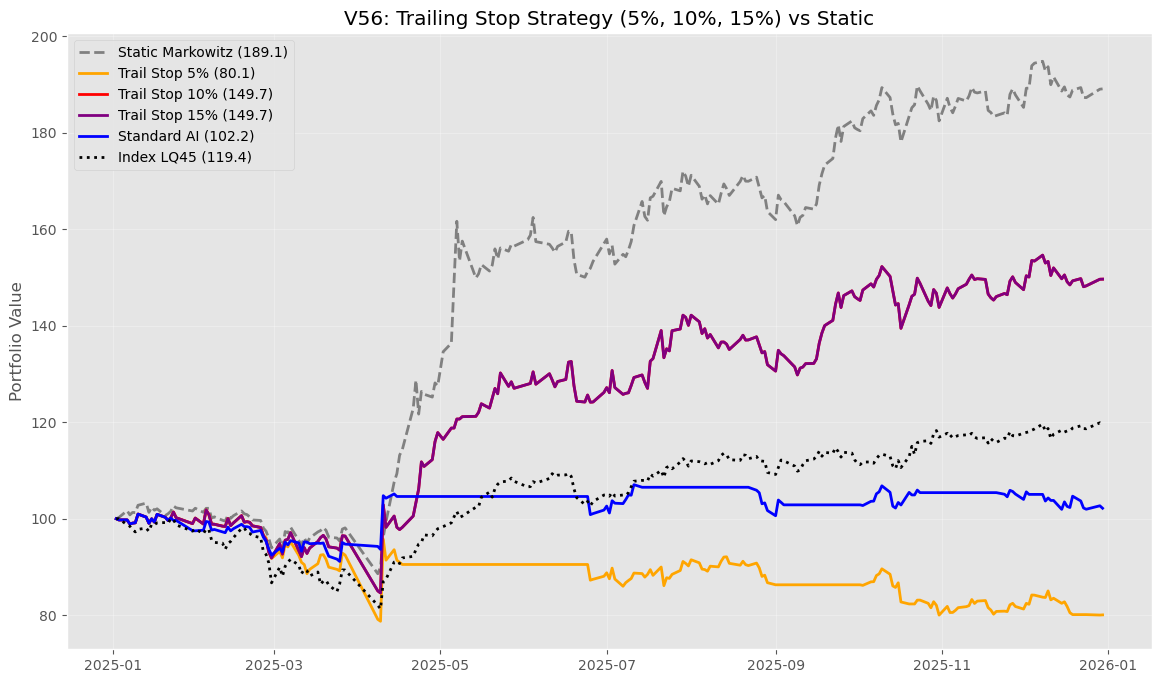


=== Performance ROI & Risk (V56) ===
           Strategy   Return %   Max DD %
0  Static Markowitz  89.111257 -14.178491
2    Trail Stop 10%  49.666116 -16.904733
3    Trail Stop 15%  49.666116 -16.904733
5        Index LQ45  19.435320 -18.695217
4       Standard AI   2.171151  -9.723880
1     Trail Stop 5% -19.933684 -22.667956
Saved results to v56_trailing_stop_results.xlsx


In [4]:
# --- 4. Run Scenarios ---
test_dates = X_test.index
fee_rate = 0.0025

results = {}

# 1. Static (Benchmark)
print("Running Static (No Stop Loss)...")
# To reuse function, set stop_loss_pct=1.0 (100% loss allowed) 
static_probs = pd.Series(1.0, index=test_probs.index)
res_static = run_simulation_trailing_stop(test_dates, returns, static_probs, 0.5, 
                                          stop_loss_pct=2.0, use_ai_exit=False, fee=fee_rate)
results['Static Markowitz'] = res_static['Portfolio_Value']

# 2. Trailing Stop 5%
print("Running Trail Stop 5% (Ignore AI Bear)...")
res_ts5 = run_simulation_trailing_stop(test_dates, returns, test_probs, opt_t, 
                                       stop_loss_pct=0.05, use_ai_exit=False, fee=fee_rate)
results['Trail Stop 5%'] = res_ts5['Portfolio_Value']

# 3. Trailing Stop 10%
print("Running Trail Stop 10% (Ignore AI Bear)...")
res_ts10 = run_simulation_trailing_stop(test_dates, returns, test_probs, opt_t, 
                                        stop_loss_pct=0.10, use_ai_exit=False, fee=fee_rate)
results['Trail Stop 10%'] = res_ts10['Portfolio_Value']

# 4. Trailing Stop 15%
print("Running Trail Stop 15% (Ignore AI Bear)...")
res_ts15 = run_simulation_trailing_stop(test_dates, returns, test_probs, opt_t, 
                                        stop_loss_pct=0.15, use_ai_exit=False, fee=fee_rate)
results['Trail Stop 15%'] = res_ts15['Portfolio_Value']

# 5. AI Standard (V47)
print("Running Standard AI (No Stop Loss)...")
res_ai = run_simulation_trailing_stop(test_dates, returns, test_probs, opt_t, 
                                      stop_loss_pct=2.0, use_ai_exit=True, fee=fee_rate)
results['Standard AI'] = res_ai['Portfolio_Value']

# Benchmark Index
benchmark = market_index.reindex(res_static.index).ffill()
benchmark = benchmark / benchmark.iloc[0] * 100
results['Index LQ45'] = benchmark

# --- 5. Visualization ---
plt.figure(figsize=(14, 8))

colors = ['gray', 'orange', 'red', 'purple', 'blue', 'black']
styles = ['--', '-', '-', '-', '-', ':']

for (name, series), color, style in zip(results.items(), colors, styles):
    plt.plot(series.index, series, label=f"{name} ({series.iloc[-1]:.1f})", color=color, linestyle=style, linewidth=2)

plt.title('V56: Trailing Stop Strategy (5%, 10%, 15%) vs Static')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('v56_trailing_stop_results.png')
plt.show()

# Summary
summary = []
for name, series in results.items():
    total_ret = (series.iloc[-1] - 100)
    peak = series.cummax()
    dd = (series - peak) / peak
    max_dd = dd.min() * 100
    summary.append({'Strategy': name, 'Return %': total_ret, 'Max DD %': max_dd})

df_summary = pd.DataFrame(summary).sort_values('Return %', ascending=False)
print("\n=== Performance ROI & Risk (V56) ===")
print(df_summary.to_string())

df_results = pd.DataFrame(results)
df_results.to_excel('v56_trailing_stop_results.xlsx', index=False)
print("Saved results to v56_trailing_stop_results.xlsx")